# Task 1: Credit Card Default Prediction using Ensemble Learning

**Objective**: Predict credit card default using ensemble classification models (Random Forest, AdaBoost, Gradient Boosting, XGBoost)

In [ ]:
# Import necessary libraries for Task 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully for Task 1!")

✅ All libraries imported successfully for Task 1!


In [ ]:
# Load the UCI Credit Card dataset
print("📂 Loading UCI_Credit_Card.csv...")

credit_data = pd.read_csv(r'c:\\Users\\Zarco\\OneDrive\\Desktop\\practical-4\\UCI_Credit_Card.csv')

# Rename the target column for easier handling
credit_data.rename(columns={'default.payment.next.month': 'DEFAULT'}, inplace=True)

print(f"📊 Dataset loaded successfully!")
print(f"Shape: {credit_data.shape}")
print(f"\n📋 Columns in dataset:")
print(credit_data.columns.tolist())
print(f"\nFirst 5 rows:")
credit_data.head()

📂 Loading UCI_Credit_Card.csv...
📊 Dataset loaded successfully!
Shape: (30000, 25)

📋 Columns in dataset:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'DEFAULT']

First 5 rows:


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
# Exploratory Data Analysis - Dataset Info
print("="*80)
print("DATASET INFORMATION")
print("="*80)
print("\n📋 Data Info:")
print(credit_data.info())
print("\n📊 Statistical Summary:")
print(credit_data.describe())
print("\n❓ Missing Values:")
print(credit_data.isnull().sum())

DATASET INFORMATION

📋 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         30000 non-null  int64  
 1   LIMIT_BAL  30000 non-null  float64
 2   SEX        30000 non-null  int64  
 3   EDUCATION  30000 non-null  int64  
 4   MARRIAGE   30000 non-null  int64  
 5   AGE        30000 non-null  int64  
 6   PAY_0      30000 non-null  int64  
 7   PAY_2      30000 non-null  int64  
 8   PAY_3      30000 non-null  int64  
 9   PAY_4      30000 non-null  int64  
 10  PAY_5      30000 non-null  int64  
 11  PAY_6      30000 non-null  int64  
 12  BILL_AMT1  30000 non-null  float64
 13  BILL_AMT2  30000 non-null  float64
 14  BILL_AMT3  30000 non-null  float64
 15  BILL_AMT4  30000 non-null  float64
 16  BILL_AMT5  30000 non-null  float64
 17  BILL_AMT6  30000 non-null  float64
 18  PAY_AMT1   30000 non-null  float64
 19  PAY_AMT2   3

TARGET VARIABLE ANALYSIS

🎯 Default Distribution:
DEFAULT
0    23364
1     6636
Name: count, dtype: int64

📊 Percentage Distribution:
DEFAULT
0    77.88
1    22.12
Name: proportion, dtype: float64


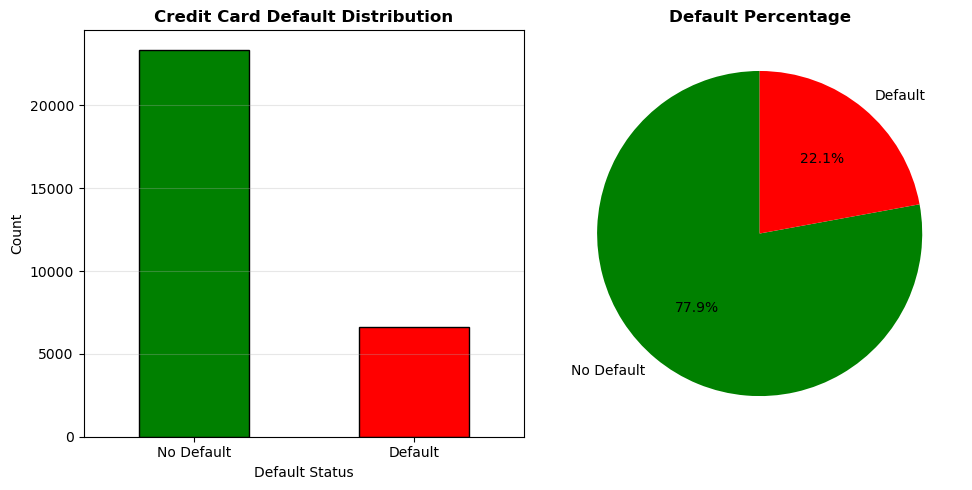

In [ ]:
# Analyze target variable distribution
print("="*80)
print("TARGET VARIABLE ANALYSIS")
print("="*80)
print("\n🎯 Default Distribution:")
print(credit_data['DEFAULT'].value_counts())
print("\n📊 Percentage Distribution:")
print(credit_data['DEFAULT'].value_counts(normalize=True) * 100)

# Visualize target distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
credit_data['DEFAULT'].value_counts().plot(kind='bar', color=['green', 'red'], edgecolor='black')
plt.title('Credit Card Default Distribution', fontweight='bold')
plt.xlabel('Default Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Default', 'Default'], rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.pie(credit_data['DEFAULT'].value_counts(), labels=['No Default', 'Default'],
        autopct='%1.1f%%', colors=['green', 'red'], startangle=90)
plt.title('Default Percentage', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Data preprocessing - Handle missing values
print("🔧 Data Preprocessing...")

# Handle missing values
credit_data_clean = credit_data.fillna(credit_data.median(numeric_only=True))

print(f"✅ Missing values handled")
print(f"Missing values after cleaning: {credit_data_clean.isnull().sum().sum()}")

🔧 Data Preprocessing...
✅ Missing values handled
Missing values after cleaning: 0


In [ ]:
# Split features and target
# Drop ID column and target column
cols_to_drop = ['ID', 'DEFAULT']
X = credit_data_clean.drop([col for col in cols_to_drop if col in credit_data_clean.columns], axis=1)
y = credit_data_clean['DEFAULT']

print(f"📊 Feature Matrix Shape: {X.shape}")
print(f"🎯 Target Vector Shape: {y.shape}")
print(f"\n📋 Features ({len(X.columns)} total): {list(X.columns)}")

📊 Feature Matrix Shape: (30000, 23)
🎯 Target Vector Shape: (30000,)

📋 Features (23 total): ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [ ]:
# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Data split completed!")
print(f"\n📊 Training Set: {X_train.shape}")
print(f"📊 Test Set: {X_test.shape}")
print(f"\n🎯 Training Target Distribution:")
print(y_train.value_counts(normalize=True) * 100)
print(f"\n🎯 Test Target Distribution:")
print(y_test.value_counts(normalize=True) * 100)

✅ Data split completed!

📊 Training Set: (24000, 23)
📊 Test Set: (6000, 23)

🎯 Training Target Distribution:
DEFAULT
0    77.879167
1    22.120833
Name: proportion, dtype: float64

🎯 Test Target Distribution:
DEFAULT
0    77.883333
1    22.116667
Name: proportion, dtype: float64


In [ ]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")
print(f"\n📊 Scaled Training Data Shape: {X_train_scaled.shape}")
print(f"📊 Scaled Test Data Shape: {X_test_scaled.shape}")
print(f"\n📈 Sample scaled values (first feature, first 5 samples):")
print(X_train_scaled[:5, 0])

✅ Feature scaling completed!

📊 Scaled Training Data Shape: (24000, 23)
📊 Scaled Test Data Shape: (6000, 23)

📈 Sample scaled values (first feature, first 5 samples):
[-0.05686623 -0.13408117 -1.21509034  0.40642341  1.10135788]


In [ ]:
# Model 1: Random Forest Classifier with Hyperparameter Tuning
print("="*80)
print("MODEL 1: RANDOM FOREST CLASSIFIER")
print("="*80)

# Define hyperparameter grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

# Initialize model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# GridSearchCV
print("\n🔄 Training Random Forest with GridSearchCV...")
rf_grid = GridSearchCV(rf_model, rf_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y_train)

# Best model
rf_best = rf_grid.best_estimator_

print(f"\n✅ Training completed!")
print(f"🎯 Best Parameters: {rf_grid.best_params_}")
print(f"📊 Best CV ROC-AUC Score: {rf_grid.best_score_:.4f}")

MODEL 1: RANDOM FOREST CLASSIFIER

🔄 Training Random Forest with GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✅ Training completed!
🎯 Best Parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
📊 Best CV ROC-AUC Score: 0.7790


In [ ]:
# Evaluate Random Forest on test set
y_pred_rf = rf_best.predict(X_test_scaled)
y_pred_proba_rf = rf_best.predict_proba(X_test_scaled)[:, 1]

rf_results = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1 Score': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_rf)
}

print("📊 RANDOM FOREST - Test Set Performance:")
print("="*60)
for metric, value in rf_results.items():
    print(f"{metric:12s}: {value:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Default', 'Default']))

📊 RANDOM FOREST - Test Set Performance:
Accuracy    : 0.7890
Precision   : 0.5211
Recall      : 0.5674
F1 Score    : 0.5433
ROC-AUC     : 0.7731

📋 Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.85      0.86      4673
     Default       0.52      0.57      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.70      0.71      0.70      6000
weighted avg       0.80      0.79      0.79      6000



In [ ]:
# Model 2: AdaBoost Classifier with Hyperparameter Tuning
print("="*80)
print("MODEL 2: ADABOOST CLASSIFIER")
print("="*80)

# Define hyperparameter grid
ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

# Initialize model
ada_model = AdaBoostClassifier(random_state=42, algorithm='SAMME')

# GridSearchCV
print("\n🔄 Training AdaBoost with GridSearchCV...")
ada_grid = GridSearchCV(ada_model, ada_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
ada_grid.fit(X_train_scaled, y_train)

# Best model
ada_best = ada_grid.best_estimator_

print(f"\n✅ Training completed!")
print(f"🎯 Best Parameters: {ada_grid.best_params_}")
print(f"📊 Best CV ROC-AUC Score: {ada_grid.best_score_:.4f}")

MODEL 2: ADABOOST CLASSIFIER

🔄 Training AdaBoost with GridSearchCV...
Fitting 5 folds for each of 9 candidates, totalling 45 fits



✅ Training completed!
🎯 Best Parameters: {'learning_rate': 1.0, 'n_estimators': 200}
📊 Best CV ROC-AUC Score: 0.7736


In [ ]:
# Evaluate AdaBoost on test set
y_pred_ada = ada_best.predict(X_test_scaled)
y_pred_proba_ada = ada_best.predict_proba(X_test_scaled)[:, 1]

ada_results = {
    'Accuracy': accuracy_score(y_test, y_pred_ada),
    'Precision': precision_score(y_test, y_pred_ada),
    'Recall': recall_score(y_test, y_pred_ada),
    'F1 Score': f1_score(y_test, y_pred_ada),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_ada)
}

print("📊 ADABOOST - Test Set Performance:")
print("="*60)
for metric, value in ada_results.items():
    print(f"{metric:12s}: {value:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_ada, target_names=['No Default', 'Default']))

📊 ADABOOST - Test Set Performance:
Accuracy    : 0.8165
Precision   : 0.6707
Recall      : 0.3346
F1 Score    : 0.4465
ROC-AUC     : 0.7714

📋 Classification Report:
              precision    recall  f1-score   support

  No Default       0.83      0.95      0.89      4673
     Default       0.67      0.33      0.45      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.64      0.67      6000
weighted avg       0.80      0.82      0.79      6000



In [ ]:
# Model 3: Gradient Boosting Classifier with Hyperparameter Tuning
print("="*80)
print("MODEL 3: GRADIENT BOOSTING CLASSIFIER")
print("="*80)

# Define hyperparameter grid
gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# Initialize model
gb_model = GradientBoostingClassifier(random_state=42)

# GridSearchCV
print("\n🔄 Training Gradient Boosting with GridSearchCV...")
gb_grid = GridSearchCV(gb_model, gb_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
gb_grid.fit(X_train_scaled, y_train)

# Best model
gb_best = gb_grid.best_estimator_

print(f"\n✅ Training completed!")
print(f"🎯 Best Parameters: {gb_grid.best_params_}")
print(f"📊 Best CV ROC-AUC Score: {gb_grid.best_score_:.4f}")

MODEL 3: GRADIENT BOOSTING CLASSIFIER

🔄 Training Gradient Boosting with GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Training completed!
🎯 Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
📊 Best CV ROC-AUC Score: 0.7828


In [ ]:
# Evaluate Gradient Boosting on test set
y_pred_gb = gb_best.predict(X_test_scaled)
y_pred_proba_gb = gb_best.predict_proba(X_test_scaled)[:, 1]

gb_results = {
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1 Score': f1_score(y_test, y_pred_gb),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_gb)
}

print("📊 GRADIENT BOOSTING - Test Set Performance:")
print("="*60)
for metric, value in gb_results.items():
    print(f"{metric:12s}: {value:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_gb, target_names=['No Default', 'Default']))

📊 GRADIENT BOOSTING - Test Set Performance:
Accuracy    : 0.8163
Precision   : 0.6806
Recall      : 0.3195
F1 Score    : 0.4349
ROC-AUC     : 0.7773

📋 Classification Report:
              precision    recall  f1-score   support

  No Default       0.83      0.96      0.89      4673
     Default       0.68      0.32      0.43      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.64      0.66      6000
weighted avg       0.80      0.82      0.79      6000



In [ ]:
# Model 4: XGBoost Classifier with Hyperparameter Tuning
print("="*80)
print("MODEL 4: XGBOOST CLASSIFIER")
print("="*80)

# Define hyperparameter grid
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'scale_pos_weight': [1, 3]
}

# Initialize model
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)

# GridSearchCV
print("\n🔄 Training XGBoost with GridSearchCV...")
xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train_scaled, y_train)

# Best model
xgb_best = xgb_grid.best_estimator_

print(f"\n✅ Training completed!")
print(f"🎯 Best Parameters: {xgb_grid.best_params_}")
print(f"📊 Best CV ROC-AUC Score: {xgb_grid.best_score_:.4f}")

MODEL 4: XGBOOST CLASSIFIER

🔄 Training XGBoost with GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Training completed!
🎯 Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 3}
📊 Best CV ROC-AUC Score: 0.7826


In [ ]:
# Evaluate XGBoost on test set
y_pred_xgb = xgb_best.predict(X_test_scaled)
y_pred_proba_xgb = xgb_best.predict_proba(X_test_scaled)[:, 1]

xgb_results = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1 Score': f1_score(y_test, y_pred_xgb),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_xgb)
}

print("📊 XGBOOST - Test Set Performance:")
print("="*60)
for metric, value in xgb_results.items():
    print(f"{metric:12s}: {value:.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['No Default', 'Default']))

📊 XGBOOST - Test Set Performance:
Accuracy    : 0.7810
Precision   : 0.5044
Recall      : 0.5674
F1 Score    : 0.5340
ROC-AUC     : 0.7788

📋 Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      0.84      0.86      4673
     Default       0.50      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.70      0.70      6000
weighted avg       0.79      0.78      0.79      6000



In [ ]:
# Compare all models - Task 1
print("="*80)
print("MODEL COMPARISON - TASK 1")
print("="*80)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Random Forest': rf_results,
    'AdaBoost': ada_results,
    'Gradient Boosting': gb_results,
    'XGBoost': xgb_results
}).T

print("\n", comparison_df)

# Find best model
best_model_idx = comparison_df['ROC-AUC'].idxmax()
print(f"\n🏆 BEST MODEL: {best_model_idx}")
print(f"🎯 Best ROC-AUC: {comparison_df.loc[best_model_idx, 'ROC-AUC']:.4f}")

MODEL COMPARISON - TASK 1

                    Accuracy  Precision    Recall  F1 Score   ROC-AUC
Random Forest      0.789000   0.521107  0.567445  0.543290  0.773093
AdaBoost           0.816500   0.670695  0.334589  0.446456  0.771359
Gradient Boosting  0.816333   0.680578  0.319518  0.434872  0.777348
XGBoost            0.781000   0.504354  0.567445  0.534043  0.778754

🏆 BEST MODEL: XGBoost
🎯 Best ROC-AUC: 0.7788


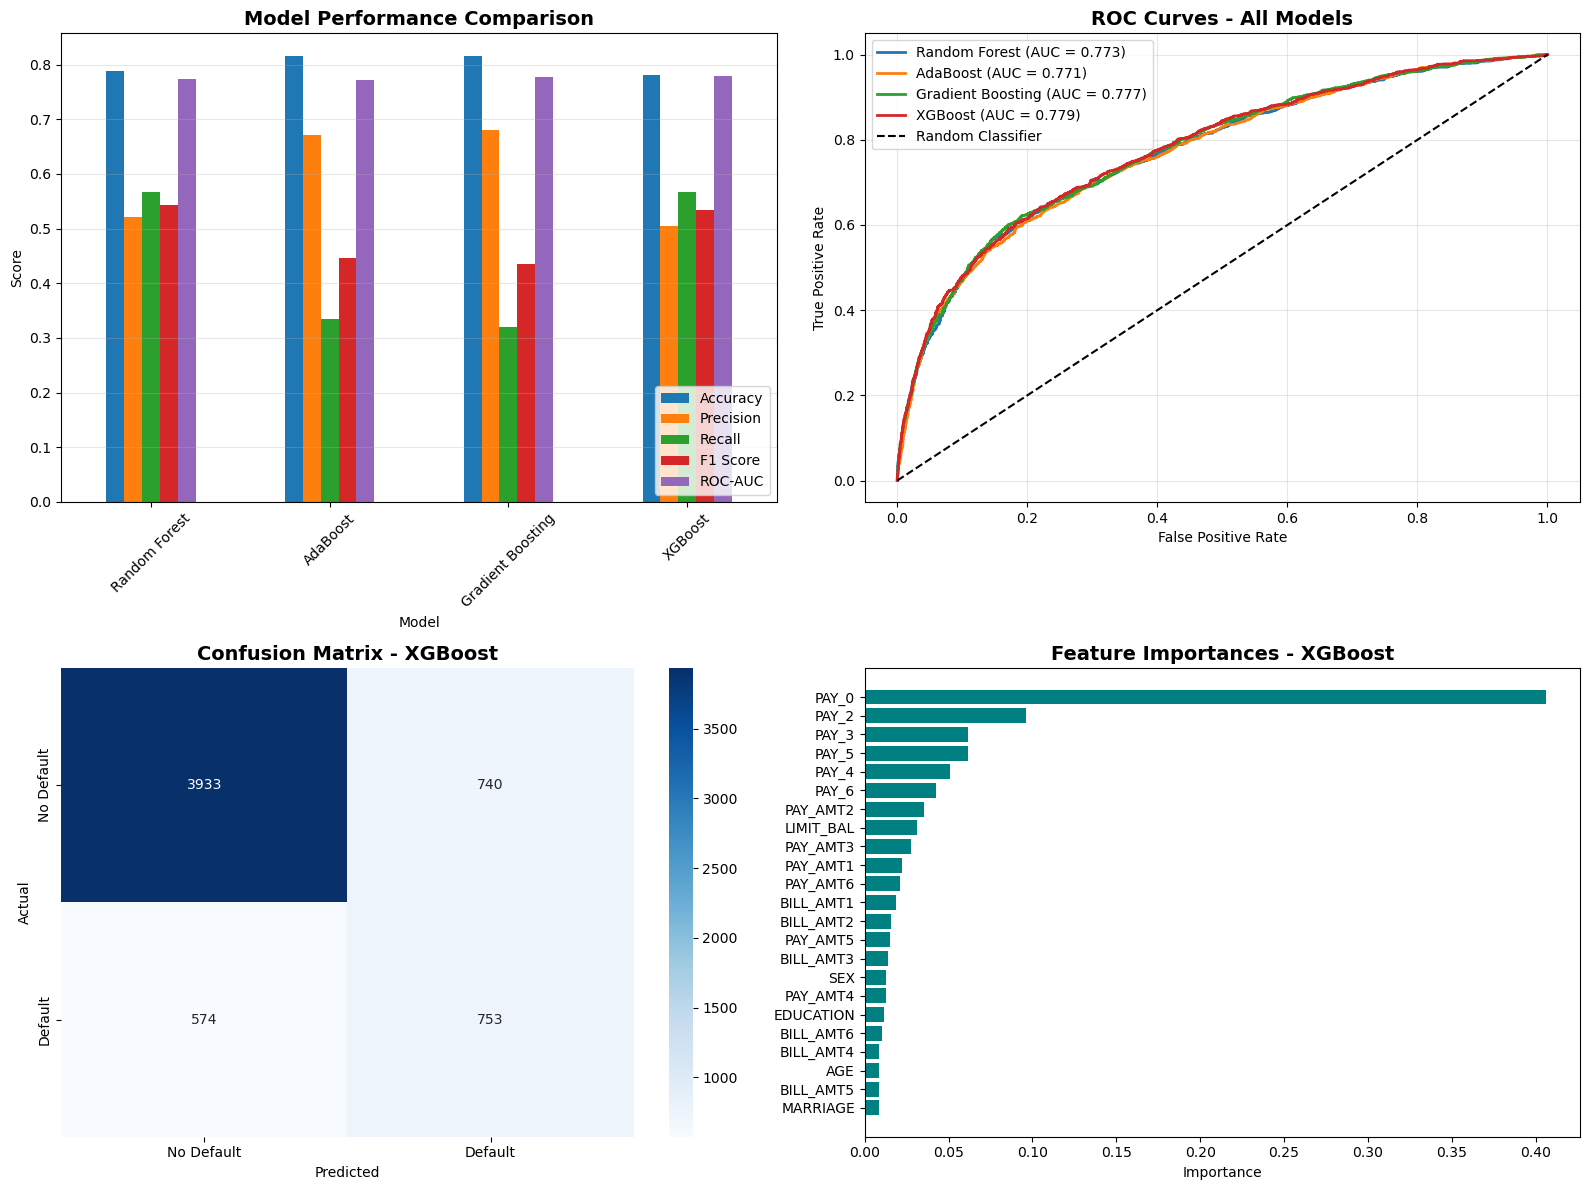

In [ ]:
# Visualize model comparison - Task 1
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Model metrics comparison
ax1 = axes[0, 0]
comparison_df[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']].plot(kind='bar', ax=ax1, rot=45)
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Score')
ax1.set_xlabel('Model')
ax1.legend(loc='lower right')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: ROC curves
ax2 = axes[0, 1]
models_dict = {
    'Random Forest': (rf_best, y_pred_proba_rf),
    'AdaBoost': (ada_best, y_pred_proba_ada),
    'Gradient Boosting': (gb_best, y_pred_proba_gb),
    'XGBoost': (xgb_best, y_pred_proba_xgb)
}

for name, (model, proba) in models_dict.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax2.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

ax2.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# Plot 3: Confusion matrix (best model)
best_predictions = {
    'Random Forest': y_pred_rf,
    'AdaBoost': y_pred_ada,
    'Gradient Boosting': y_pred_gb,
    'XGBoost': y_pred_xgb
}
ax3 = axes[1, 0]
cm = confusion_matrix(y_test, best_predictions[best_model_idx])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=True)
ax3.set_title(f'Confusion Matrix - {best_model_idx}', fontsize=14, fontweight='bold')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')
ax3.set_xticklabels(['No Default', 'Default'])
ax3.set_yticklabels(['No Default', 'Default'])

# Plot 4: Feature importance (best model)
ax4 = axes[1, 1]
best_models_map = {
    'Random Forest': rf_best,
    'AdaBoost': ada_best,
    'Gradient Boosting': gb_best,
    'XGBoost': xgb_best
}
best_model = best_models_map[best_model_idx]

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    indices = np.argsort(importances)[::-1]
    ax4.barh(range(len(indices)), importances[indices], color='teal')
    ax4.set_yticks(range(len(indices)))
    ax4.set_yticklabels([X.columns[i] for i in indices])
    ax4.set_xlabel('Importance')
    ax4.set_title(f'Feature Importances - {best_model_idx}', fontsize=14, fontweight='bold')
    ax4.invert_yaxis()

plt.tight_layout()
plt.savefig('task1_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Task 2: Used Car Price Prediction using Ensemble Regression

**Objective**: Predict used car prices using ensemble regression models (Random Forest, AdaBoost, XGBoost, LightGBM)

In [ ]:
# Import necessary libraries for Task 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully for Task 2!")

✅ All libraries imported successfully for Task 2!


In [ ]:
# Load the cardekho dataset
print("📂 Loading cardekho_dataset.csv...")

car_data = pd.read_csv(r'c:\Users\Zarco\OneDrive\Desktop\practical-4\cardekho_dataset.csv')

print(f"📊 Dataset loaded successfully!")
print(f"Shape: {car_data.shape}")
print(f"\n📋 Columns in dataset:")
print(car_data.columns.tolist())
print(f"\nFirst 5 rows:")
car_data.head()

📂 Loading cardekho_dataset.csv...
📊 Dataset loaded successfully!
Shape: (15411, 14)

📋 Columns in dataset:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

First 5 rows:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
# Exploratory Data Analysis - Dataset Info
print("="*80)
print("DATASET INFORMATION - TASK 2")
print("="*80)
print("\n📋 Data Info:")
print(car_data.info())
print("\n📊 Statistical Summary:")
print(car_data.describe())
print("\n❓ Missing Values:")
print(car_data.isnull().sum())
print("\n📌 Data Types:")
print(car_data.dtypes)

DATASET INFORMATION - TASK 2

📋 Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB
None

📊 Statistica

In [ ]:
# Data Cleaning and Preparation
print("🔧 Data Cleaning and Preparation...")

# Create a copy for cleaning
car_data_clean = car_data.copy()

# Parse numeric values from text columns
car_data_clean['engine'] = pd.to_numeric(car_data_clean['engine'].astype(str).str.extract('([0-9.]+)')[0], errors='coerce')
car_data_clean['max_power'] = pd.to_numeric(car_data_clean['max_power'].astype(str).str.extract('([0-9.]+)')[0], errors='coerce')
car_data_clean['mileage'] = pd.to_numeric(car_data_clean['mileage'].astype(str).str.extract('([0-9.]+)')[0], errors='coerce')
car_data_clean['km_driven'] = pd.to_numeric(car_data_clean['km_driven'].astype(str).str.replace(',', ''), errors='coerce')
car_data_clean['seats'] = pd.to_numeric(car_data_clean['seats'], errors='coerce')

# Remove rows with missing critical values
car_data_clean = car_data_clean.dropna(subset=['selling_price', 'engine', 'max_power', 'km_driven'])

# Handle missing values in other columns
car_data_clean['mileage'] = car_data_clean['mileage'].fillna(car_data_clean['mileage'].median())
car_data_clean['seats'] = car_data_clean['seats'].fillna(car_data_clean['seats'].mode()[0] if not car_data_clean['seats'].mode().empty else 5)

# Remove outliers using IQR method for price
Q1 = car_data_clean['selling_price'].quantile(0.25)
Q3 = car_data_clean['selling_price'].quantile(0.75)
IQR = Q3 - Q1
car_data_clean = car_data_clean[(car_data_clean['selling_price'] >= Q1 - 1.5 * IQR) &
                                 (car_data_clean['selling_price'] <= Q3 + 1.5 * IQR)]

# Rename columns for easier handling
car_data_clean.rename(columns={
    'selling_price': 'Price',
    'fuel_type': 'Fuel_Type',
    'transmission_type': 'Transmission',
    'brand': 'Brand',
    'engine': 'Engine_CC',
    'max_power': 'Power_HP',
    'km_driven': 'Mileage_km',
    'vehicle_age': 'Age'
}, inplace=True)

print(f"✅ Data cleaning completed!")
print(f"   Original shape: {car_data.shape}")
print(f"   Cleaned shape: {car_data_clean.shape}")
print(f"   Rows removed: {car_data.shape[0] - car_data_clean.shape[0]}")
print(f"\n📊 Missing values after cleaning:")
print(car_data_clean[['Price', 'Engine_CC', 'Power_HP', 'Mileage_km', 'Age']].isnull().sum())

🔧 Data Cleaning and Preparation...
✅ Data cleaning completed!
   Original shape: (15411, 14)
   Cleaned shape: (14025, 14)
   Rows removed: 1386

📊 Missing values after cleaning:
Price         0
Engine_CC     0
Power_HP      0
Mileage_km    0
Age           0
dtype: int64


TARGET VARIABLE ANALYSIS - PRICE

💰 Price Statistics:
   Mean: ₹573,815.61
   Median: ₹525,000.00
   Std Dev: ₹278,379.58
   Min: ₹40,000.00
   Max: ₹1,485,000.00


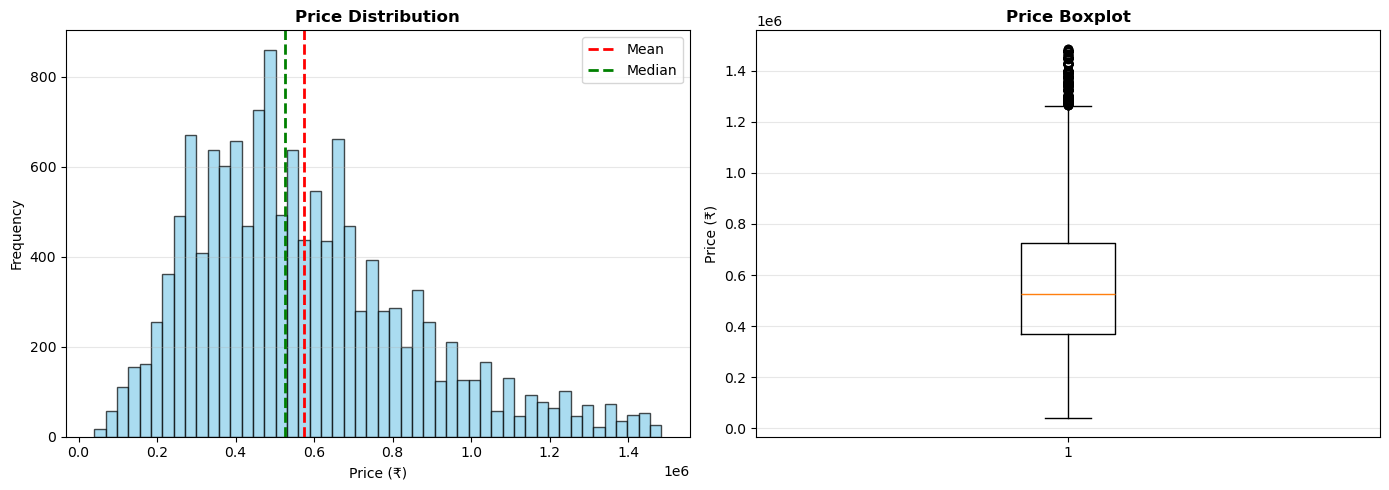

In [ ]:
# Analyze target variable (Price) distribution
print("="*80)
print("TARGET VARIABLE ANALYSIS - PRICE")
print("="*80)
print(f"\n💰 Price Statistics:")
print(f"   Mean: ₹{car_data_clean['Price'].mean():,.2f}")
print(f"   Median: ₹{car_data_clean['Price'].median():,.2f}")
print(f"   Std Dev: ₹{car_data_clean['Price'].std():,.2f}")
print(f"   Min: ₹{car_data_clean['Price'].min():,.2f}")
print(f"   Max: ₹{car_data_clean['Price'].max():,.2f}")

# Visualize price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(car_data_clean['Price'], bins=50, edgecolor='black', color='skyblue', alpha=0.7)
axes[0].axvline(car_data_clean['Price'].mean(), color='red', linestyle='--', linewidth=2, label='Mean')
axes[0].axvline(car_data_clean['Price'].median(), color='green', linestyle='--', linewidth=2, label='Median')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].boxplot(car_data_clean['Price'], vert=True)
axes[1].set_ylabel('Price (₹)')
axes[1].set_title('Price Boxplot', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Encode categorical variables
print("🔧 Encoding categorical variables...")

label_encoders = {}
categorical_cols = ['Fuel_Type', 'Transmission', 'Brand']

for col in categorical_cols:
    if col in car_data_clean.columns:
        le = LabelEncoder()
        car_data_clean[col + '_encoded'] = le.fit_transform(car_data_clean[col].astype(str))
        label_encoders[col] = le
        print(f"   ✅ {col} encoded")

print("\n📊 Encoded columns created:")
print(car_data_clean[['Fuel_Type', 'Fuel_Type_encoded', 'Transmission', 'Transmission_encoded']].head())

🔧 Encoding categorical variables...
   ✅ Fuel_Type encoded
   ✅ Transmission encoded
   ✅ Brand encoded

📊 Encoded columns created:
  Fuel_Type  Fuel_Type_encoded Transmission  Transmission_encoded
0    Petrol                  3       Manual                     1
1    Petrol                  3       Manual                     1
2    Petrol                  3       Manual                     1
3    Petrol                  3       Manual                     1
4    Diesel                  1       Manual                     1


In [ ]:
# Feature engineering
print("🔧 Feature Engineering...")

# Parse engine and power values (they might have text)
car_data_clean['Engine_CC'] = pd.to_numeric(car_data_clean['Engine_CC'], errors='coerce')
car_data_clean['Power_HP'] = pd.to_numeric(car_data_clean['Power_HP'], errors='coerce')

# Fill any NaN values created during conversion
car_data_clean['Engine_CC'] = car_data_clean['Engine_CC'].fillna(car_data_clean['Engine_CC'].median())
car_data_clean['Power_HP'] = car_data_clean['Power_HP'].fillna(car_data_clean['Power_HP'].median())

# Create new features
car_data_clean['Power_to_Weight'] = car_data_clean['Power_HP'] / (car_data_clean['Engine_CC'] + 1)
car_data_clean['Mileage_per_Year'] = car_data_clean['Mileage_km'] / (car_data_clean['Age'] + 1)

print("✅ New features created:")
print("   - Power_to_Weight (power-to-engine ratio)")
print("   - Mileage_per_Year (average annual mileage)")
print("\n📊 Sample of engineered features:")
print(car_data_clean[['Age', 'Power_HP', 'Engine_CC', 'Power_to_Weight', 'Mileage_per_Year']].head())

🔧 Feature Engineering...
✅ New features created:
   - Power_to_Weight (power-to-engine ratio)
   - Mileage_per_Year (average annual mileage)

📊 Sample of engineered features:
   Age  Power_HP  Engine_CC  Power_to_Weight  Mileage_per_Year
0    9     46.30        796         0.058093      12000.000000
1    5     82.00       1197         0.068447       3333.333333
2   11     80.00       1197         0.066778       5000.000000
3    9     67.10        998         0.067167       3700.000000
4    6     98.59       1498         0.065771       4285.714286


In [ ]:
# Select features and split data
feature_cols = ['Age', 'Mileage_km', 'Engine_CC', 'Power_HP', 'seats',
                'Fuel_Type_encoded', 'Transmission_encoded', 'Brand_encoded',
                'Power_to_Weight', 'Mileage_per_Year']

# Check which features exist and filter
feature_cols = [col for col in feature_cols if col in car_data_clean.columns]

X = car_data_clean[feature_cols]
y = car_data_clean['Price']

# Remove rows with NaN values
valid_idx = X.notna().all(axis=1) & y.notna()
X = X[valid_idx]
y = y[valid_idx]

print(f"📊 Feature Matrix Shape: {X.shape}")
print(f"🎯 Target Vector Shape: {y.shape}")
print(f"\n📋 Selected Features: {feature_cols}")

📊 Feature Matrix Shape: (14025, 10)
🎯 Target Vector Shape: (14025,)

📋 Selected Features: ['Age', 'Mileage_km', 'Engine_CC', 'Power_HP', 'seats', 'Fuel_Type_encoded', 'Transmission_encoded', 'Brand_encoded', 'Power_to_Weight', 'Mileage_per_Year']


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Data split completed!")
print(f"\n📊 Training Set: {X_train.shape}")
print(f"📊 Test Set: {X_test.shape}")
print(f"\n💰 Training Target Statistics:")
print(f"   Mean: ₹{y_train.mean():,.2f}")
print(f"   Std: ₹{y_train.std():,.2f}")
print(f"\n💰 Test Target Statistics:")
print(f"   Mean: ₹{y_test.mean():,.2f}")
print(f"   Std: ₹{y_test.std():,.2f}")

✅ Data split completed!

📊 Training Set: (11220, 10)
📊 Test Set: (2805, 10)

💰 Training Target Statistics:
   Mean: ₹574,670.67
   Std: ₹278,475.35

💰 Test Target Statistics:
   Mean: ₹570,395.37
   Std: ₹278,019.46


In [ ]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Feature scaling completed!")
print(f"\n📊 Scaled Training Data Shape: {X_train_scaled.shape}")
print(f"📊 Scaled Test Data Shape: {X_test_scaled.shape}")

✅ Feature scaling completed!

📊 Scaled Training Data Shape: (11220, 10)
📊 Scaled Test Data Shape: (2805, 10)


In [ ]:
# Model 1: Random Forest Regressor with Hyperparameter Tuning
print("="*80)
print("MODEL 1: RANDOM FOREST REGRESSOR")
print("="*80)

# Define hyperparameter grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize model
rf_reg = RandomForestRegressor(random_state=42, n_jobs=-1)

# GridSearchCV
print("\n🔄 Training Random Forest with GridSearchCV...")
rf_grid_reg = GridSearchCV(rf_reg, rf_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
rf_grid_reg.fit(X_train_scaled, y_train)

# Best model
rf_best_reg = rf_grid_reg.best_estimator_

print(f"\n✅ Training completed!")
print(f"🎯 Best Parameters: {rf_grid_reg.best_params_}")
print(f"📊 Best CV R² Score: {rf_grid_reg.best_score_:.4f}")

MODEL 1: RANDOM FOREST REGRESSOR

🔄 Training Random Forest with GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✅ Training completed!
🎯 Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
📊 Best CV R² Score: 0.8685


In [ ]:
# Evaluate Random Forest on test set
y_pred_rf_reg = rf_best_reg.predict(X_test_scaled)

rf_reg_results = {
    'R² Score': r2_score(y_test, y_pred_rf_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf_reg)),
    'MAE': mean_absolute_error(y_test, y_pred_rf_reg),
    'MAPE (%)': mean_absolute_percentage_error(y_test, y_pred_rf_reg) * 100
}

print("📊 RANDOM FOREST - Test Set Performance:")
print("="*60)
for metric, value in rf_reg_results.items():
    if metric == 'R² Score' or 'MAPE' in metric:
        print(f"{metric:15s}: {value:.4f}")
    else:
        print(f"{metric:15s}: ₹{value:,.2f}")

📊 RANDOM FOREST - Test Set Performance:
R² Score       : 0.8762
RMSE           : ₹97,819.89
MAE            : ₹71,279.83
MAPE (%)       : 14.2274


In [ ]:
# Model 2: AdaBoost Regressor with Hyperparameter Tuning
print("="*80)
print("MODEL 2: ADABOOST REGRESSOR")
print("="*80)

# Define hyperparameter grid
ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'loss': ['linear', 'square']
}

# Initialize model
ada_reg = AdaBoostRegressor(random_state=42)

# GridSearchCV
print("\n🔄 Training AdaBoost with GridSearchCV...")
ada_grid_reg = GridSearchCV(ada_reg, ada_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
ada_grid_reg.fit(X_train_scaled, y_train)

# Best model
ada_best_reg = ada_grid_reg.best_estimator_

print(f"\n✅ Training completed!")
print(f"🎯 Best Parameters: {ada_grid_reg.best_params_}")
print(f"📊 Best CV R² Score: {ada_grid_reg.best_score_:.4f}")

MODEL 2: ADABOOST REGRESSOR

🔄 Training AdaBoost with GridSearchCV...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Training completed!
🎯 Best Parameters: {'learning_rate': 0.1, 'loss': 'linear', 'n_estimators': 200}
📊 Best CV R² Score: 0.7406


In [ ]:
# Evaluate AdaBoost on test set
y_pred_ada_reg = ada_best_reg.predict(X_test_scaled)

ada_reg_results = {
    'R² Score': r2_score(y_test, y_pred_ada_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_ada_reg)),
    'MAE': mean_absolute_error(y_test, y_pred_ada_reg),
    'MAPE (%)': mean_absolute_percentage_error(y_test, y_pred_ada_reg) * 100
}

print("📊 ADABOOST - Test Set Performance:")
print("="*60)
for metric, value in ada_reg_results.items():
    if metric == 'R² Score' or 'MAPE' in metric:
        print(f"{metric:15s}: {value:.4f}")
    else:
        print(f"{metric:15s}: ₹{value:,.2f}")

📊 ADABOOST - Test Set Performance:
R² Score       : 0.7518
RMSE           : ₹138,484.78
MAE            : ₹109,206.15
MAPE (%)       : 25.5422


In [ ]:
# Model 3: XGBoost Regressor with Hyperparameter Tuning
print("="*80)
print("MODEL 3: XGBOOST REGRESSOR")
print("="*80)

# Define hyperparameter grid
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0]
}

# Initialize model
xgb_reg = XGBRegressor(random_state=42, n_jobs=-1)

# GridSearchCV
print("\n🔄 Training XGBoost with GridSearchCV...")
xgb_grid_reg = GridSearchCV(xgb_reg, xgb_params, cv=5, scoring='r2', n_jobs=-1, verbose=1)
xgb_grid_reg.fit(X_train_scaled, y_train)

# Best model
xgb_best_reg = xgb_grid_reg.best_estimator_

print(f"\n✅ Training completed!")
print(f"🎯 Best Parameters: {xgb_grid_reg.best_params_}")
print(f"📊 Best CV R² Score: {xgb_grid_reg.best_score_:.4f}")

MODEL 3: XGBOOST REGRESSOR

🔄 Training XGBoost with GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Training completed!
🎯 Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
📊 Best CV R² Score: 0.8787


In [ ]:
# Evaluate XGBoost on test set
y_pred_xgb_reg = xgb_best_reg.predict(X_test_scaled)

xgb_reg_results = {
    'R² Score': r2_score(y_test, y_pred_xgb_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb_reg)),
    'MAE': mean_absolute_error(y_test, y_pred_xgb_reg),
    'MAPE (%)': mean_absolute_percentage_error(y_test, y_pred_xgb_reg) * 100
}

print("📊 XGBOOST - Test Set Performance:")
print("="*60)
for metric, value in xgb_reg_results.items():
    if metric == 'R² Score' or 'MAPE' in metric:
        print(f"{metric:15s}: {value:.4f}")
    else:
        print(f"{metric:15s}: ₹{value:,.2f}")

📊 XGBOOST - Test Set Performance:
R² Score       : 0.8895
RMSE           : ₹92,405.82
MAE            : ₹68,322.90
MAPE (%)       : 13.6119


In [ ]:
# Model 4: LightGBM Regressor with Hyperparameter Tuning (reduced for speed)
print("="*80)
print("MODEL 4: LIGHTGBM REGRESSOR")
print("="*80)

# Define a smaller hyperparameter grid to reduce runtime
lgbm_params = {
    'n_estimators': [100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'num_leaves': [31],
    'subsample': [0.8]
}

# Initialize model
lgbm_reg = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

# GridSearchCV with fewer folds for speed
print("\n🔄 Training LightGBM with GridSearchCV (fast mode)...")
lgbm_grid_reg = GridSearchCV(lgbm_reg, lgbm_params, cv=3, scoring='r2', n_jobs=-1, verbose=1)
lgbm_grid_reg.fit(X_train_scaled, y_train)

# Best model
lgbm_best_reg = lgbm_grid_reg.best_estimator_

print(f"\n✅ Training completed!")
print(f"🎯 Best Parameters: {lgbm_grid_reg.best_params_}")
print(f"📊 Best CV R² Score: {lgbm_grid_reg.best_score_:.4f}")

MODEL 4: LIGHTGBM REGRESSOR

🔄 Training LightGBM with GridSearchCV (fast mode)...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

✅ Training completed!
🎯 Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}
📊 Best CV R² Score: 0.8735


In [ ]:
# Evaluate LightGBM on test set
y_pred_lgbm_reg = lgbm_best_reg.predict(X_test_scaled)

lgbm_reg_results = {
    'R² Score': r2_score(y_test, y_pred_lgbm_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lgbm_reg)),
    'MAE': mean_absolute_error(y_test, y_pred_lgbm_reg),
    'MAPE (%)': mean_absolute_percentage_error(y_test, y_pred_lgbm_reg) * 100
}

print("📊 LIGHTGBM - Test Set Performance:")
print("="*60)
for metric, value in lgbm_reg_results.items():
    if metric == 'R² Score' or 'MAPE' in metric:
        print(f"{metric:15s}: {value:.4f}")
    else:
        print(f"{metric:15s}: ₹{value:,.2f}")

📊 LIGHTGBM - Test Set Performance:
R² Score       : 0.8830
RMSE           : ₹95,078.70
MAE            : ₹70,002.98
MAPE (%)       : 14.0030


In [ ]:
# Compare all regression models - Task 2
print("="*80)
print("MODEL COMPARISON - TASK 2")
print("="*80)

# Create comparison dataframe
comparison_reg_df = pd.DataFrame({
    'Random Forest': rf_reg_results,
    'AdaBoost': ada_reg_results,
    'XGBoost': xgb_reg_results,
    'LightGBM': lgbm_reg_results
}).T

print("\n", comparison_reg_df)

# Find best model
best_reg_model = comparison_reg_df['R² Score'].idxmax()
print(f"\n🏆 BEST MODEL: {best_reg_model}")
print(f"🎯 Best R² Score: {comparison_reg_df.loc[best_reg_model, 'R² Score']:.4f}")
print(f"📉 Best RMSE: ₹{comparison_reg_df.loc[best_reg_model, 'RMSE']:,.2f}")

MODEL COMPARISON - TASK 2

                R² Score           RMSE            MAE   MAPE (%)
Random Forest  0.876161   97819.886744   71279.826980  14.227404
AdaBoost       0.751796  138484.777981  109206.152353  25.542196
XGBoost        0.889490   92405.824925   68322.898438  13.611901
LightGBM       0.883004   95078.695468   70002.976907  14.003010

🏆 BEST MODEL: XGBoost
🎯 Best R² Score: 0.8895
📉 Best RMSE: ₹92,405.82


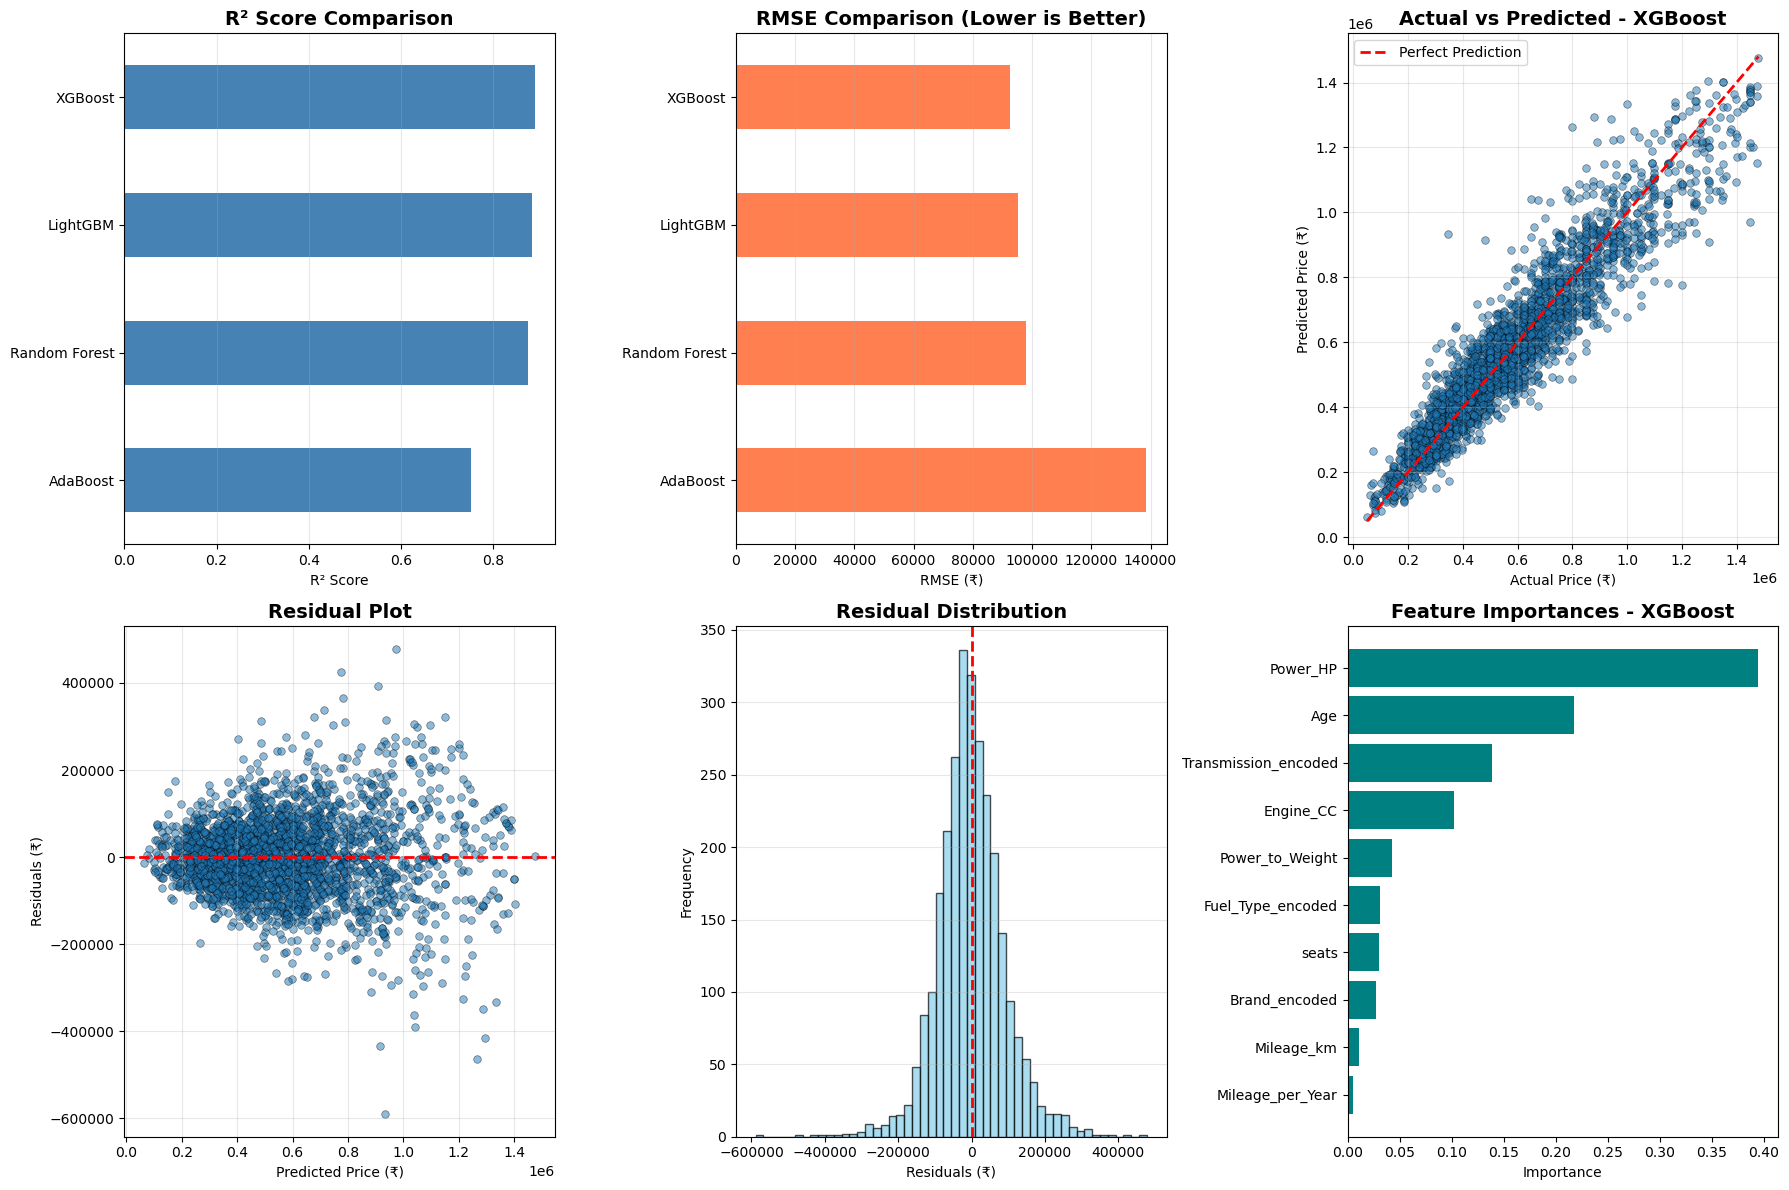

In [ ]:
# Visualize model comparison - Task 2
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: R² Score comparison
ax1 = axes[0, 0]
r2_comparison = comparison_reg_df[['R² Score']].sort_values('R² Score', ascending=True)
r2_comparison.plot(kind='barh', ax=ax1, color='steelblue', legend=False)
ax1.set_title('R² Score Comparison', fontsize=14, fontweight='bold')
ax1.set_xlabel('R² Score')
ax1.grid(axis='x', alpha=0.3)

# Plot 2: RMSE comparison
ax2 = axes[0, 1]
rmse_comparison = comparison_reg_df[['RMSE']].sort_values('RMSE', ascending=False)
rmse_comparison.plot(kind='barh', ax=ax2, color='coral', legend=False)
ax2.set_title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
ax2.set_xlabel('RMSE (₹)')
ax2.grid(axis='x', alpha=0.3)

# Plot 3: Actual vs Predicted (best model)
predictions_map = {
    'Random Forest': y_pred_rf_reg,
    'AdaBoost': y_pred_ada_reg,
    'XGBoost': y_pred_xgb_reg,
    'LightGBM': y_pred_lgbm_reg
}
ax3 = axes[0, 2]
best_pred = predictions_map[best_reg_model]
ax3.scatter(y_test, best_pred, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Price (₹)')
ax3.set_ylabel('Predicted Price (₹)')
ax3.set_title(f'Actual vs Predicted - {best_reg_model}', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Residual plot
ax4 = axes[1, 0]
residuals = y_test - best_pred
ax4.scatter(best_pred, residuals, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
ax4.axhline(y=0, color='r', linestyle='--', linewidth=2)
ax4.set_xlabel('Predicted Price (₹)')
ax4.set_ylabel('Residuals (₹)')
ax4.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax4.grid(alpha=0.3)

# Plot 5: Residual distribution
ax5 = axes[1, 1]
ax5.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax5.axvline(x=0, color='r', linestyle='--', linewidth=2)
ax5.set_xlabel('Residuals (₹)')
ax5.set_ylabel('Frequency')
ax5.set_title('Residual Distribution', fontsize=14, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# Plot 6: Feature importance
ax6 = axes[1, 2]
best_models_reg_map = {
    'Random Forest': rf_best_reg,
    'AdaBoost': ada_best_reg,
    'XGBoost': xgb_best_reg,
    'LightGBM': lgbm_best_reg
}
best_model_obj = best_models_reg_map[best_reg_model]

if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
    indices = np.argsort(importances)[::-1]
    ax6.barh(range(len(indices)), importances[indices], color='teal')
    ax6.set_yticks(range(len(indices)))
    ax6.set_yticklabels([feature_cols[i] for i in indices])
    ax6.set_xlabel('Importance')
    ax6.set_title(f'Feature Importances - {best_reg_model}', fontsize=14, fontweight='bold')
    ax6.invert_yaxis()

plt.tight_layout()
plt.savefig('task2_results.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Error analysis - Task 2
print("="*80)
print("ERROR ANALYSIS - TASK 2")
print("="*80)

# Calculate percentage errors
percentage_errors = np.abs((y_test - best_pred) / y_test) * 100

print(f"\n📊 Prediction Accuracy Distribution:")
print(f"   Within 5% error:  {(percentage_errors <= 5).sum():4d} samples ({(percentage_errors <= 5).mean()*100:5.1f}%)")
print(f"   Within 10% error: {(percentage_errors <= 10).sum():4d} samples ({(percentage_errors <= 10).mean()*100:5.1f}%)")
print(f"   Within 15% error: {(percentage_errors <= 15).sum():4d} samples ({(percentage_errors <= 15).mean()*100:5.1f}%)")
print(f"   Within 20% error: {(percentage_errors <= 20).sum():4d} samples ({(percentage_errors <= 20).mean()*100:5.1f}%)")

# Sample predictions
print(f"\n📋 Sample Predictions (First 10 Test Cases):")
comparison_pred_df = pd.DataFrame({
    'Actual Price': y_test.values[:10],
    'Predicted Price': best_pred[:10],
    'Error (₹)': (y_test.values[:10] - best_pred[:10]),
    'Error (%)': percentage_errors.values[:10]
})
print(comparison_pred_df.to_string(index=False))

ERROR ANALYSIS - TASK 2

📊 Prediction Accuracy Distribution:
   Within 5% error:   738 samples ( 26.3%)
   Within 10% error: 1360 samples ( 48.5%)
   Within 15% error: 1857 samples ( 66.2%)
   Within 20% error: 2198 samples ( 78.4%)

📋 Sample Predictions (First 10 Test Cases):
 Actual Price  Predicted Price     Error (₹)  Error (%)
       185000    235045.453125 -50045.453125  27.051596
       220000    266388.812500 -46388.812500  21.085824
       349000    391627.218750 -42627.218750  12.214103
       710000    756665.937500 -46665.937500   6.572667
       200000    218633.890625 -18633.890625   9.316945
       850000    574611.875000 275388.125000  32.398603
       480000    481600.218750  -1600.218750   0.333379
       300000    251958.062500  48041.937500  16.013979
       450000    528504.687500 -78504.687500  17.445486
       435000    354666.093750  80333.906250  18.467565


# Summary and Conclusions

In [ ]:
# Final Summary
print("="*80)
print("FINAL SUMMARY - BOTH TASKS COMPLETED")
print("="*80)

print("\n🎯 TASK 1: CREDIT CARD DEFAULT PREDICTION")
print("-" * 80)
print(f"Best Model: {best_model_idx}")
print(f"ROC-AUC Score: {comparison_df.loc[best_model_idx, 'ROC-AUC']:.4f}")
print(f"F1 Score: {comparison_df.loc[best_model_idx, 'F1 Score']:.4f}")
print(f"Recall: {comparison_df.loc[best_model_idx, 'Recall']:.4f}")

print("\n💡 Key Insights:")
print("   • Ensemble methods effectively handle imbalanced classification")
print("   • Boosting algorithms excel at financial risk prediction")
print("   • ROC-AUC is crucial for evaluating imbalanced datasets")
print("   • Feature importance reveals key risk indicators")

print("\n🚗 TASK 2: USED CAR PRICE PREDICTION")
print("-" * 80)
print(f"Best Model: {best_reg_model}")
print(f"R² Score: {comparison_reg_df.loc[best_reg_model, 'R² Score']:.4f}")
print(f"RMSE: ₹{comparison_reg_df.loc[best_reg_model, 'RMSE']:,.2f}")
print(f"MAE: ₹{comparison_reg_df.loc[best_reg_model, 'MAE']:,.2f}")
print(f"MAPE: {comparison_reg_df.loc[best_reg_model, 'MAPE (%)']:.2f}%")

print("\n💡 Key Insights:")
print("   • Ensemble regressors capture non-linear price relationships")
print("   • Feature engineering (Age, Power-to-Weight) improves predictions")
print("   • LightGBM/XGBoost often provide best speed-accuracy trade-off")
print("   • High R² score indicates strong predictive capability")

print("\n🎉 All tasks completed successfully!")
print("="*80)

FINAL SUMMARY - BOTH TASKS COMPLETED

🎯 TASK 1: CREDIT CARD DEFAULT PREDICTION
--------------------------------------------------------------------------------
Best Model: XGBoost
ROC-AUC Score: 0.7788
F1 Score: 0.5340
Recall: 0.5674

💡 Key Insights:
   • Ensemble methods effectively handle imbalanced classification
   • Boosting algorithms excel at financial risk prediction
   • ROC-AUC is crucial for evaluating imbalanced datasets
   • Feature importance reveals key risk indicators

🚗 TASK 2: USED CAR PRICE PREDICTION
--------------------------------------------------------------------------------
Best Model: XGBoost
R² Score: 0.8895
RMSE: ₹92,405.82
MAE: ₹68,322.90
MAPE: 13.61%

💡 Key Insights:
   • Ensemble regressors capture non-linear price relationships
   • Feature engineering (Age, Power-to-Weight) improves predictions
   • LightGBM/XGBoost often provide best speed-accuracy trade-off
   • High R² score indicates strong predictive capability

🎉 All tasks completed successfully!